<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Importancia del Preprocesamiento de Datos 🧹
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Machine Learning
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 00
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Machine%20Learning/00%20-%20Introduccion%20al%20Machine%20Learning/03_Importancia_del_Preprocesamiento.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## Objetivos de Aprendizaje 🔎

Este cuaderno cierra el Capítulo 1 con la **Sección 1.6 (Importancia del preprocesamiento de datos)**. Muestra con números —no solo con argumentos— por qué preparar los datos es tan decisivo como elegir el algoritmo.

Al terminar podrás:

1. **Explicar** el principio *Garbage In, Garbage Out* (GIGO) y sus cuatro frentes: valores faltantes, escalas distintas, variables categóricas y valores atípicos.
2. **Cuantificar** el efecto del preprocesamiento comparando el **mismo modelo** con datos crudos y con datos progresivamente preparados.
3. **Reconocer y evitar la fuga de datos** (*data leakage*): fuga de la variable objetivo y contaminación entre entrenamiento y prueba.
4. **Construir** un `Pipeline` con `ColumnTransformer` que ajusta todas las transformaciones **solo con el conjunto de entrenamiento**.
5. **Aplicar** un checklist de preprocesamiento y saber dónde profundizar.

> 📍 **Dónde estamos:** Módulo 00, cuaderno 3 de 3 (después de [Tipos de Problemas en ML](02_Tipos_de_Problemas_en_ML.ipynb)).

> 🔗 **Este cuaderno es el "porqué"; el "cómo" detallado está en otros cursos.** Las técnicas de imputación, outliers, escalado y codificación se desarrollan en [Data Mining — Módulo 01](../../Data%20Mining/01%20-%20Preprocesamiento%20de%20los%20Datos/00_Tratamiento_de_Valores_Faltantes_e_Imputacion.ipynb) y en [Data Science Programming — Módulo 05](../../Data%20Science%20programming/05%20-%20Data%20Preparation/00_Introduccion_Data_Preparation.ipynb). Aquí las usamos para demostrar su **impacto en el aprendizaje**.

---
## Recursos Recomendados 📚

### 📖 Libros de Referencia:
- *Hands-On Machine Learning with Scikit-Learn and PyTorch* — **Aurélien Géron** (O'Reilly, 2025). Cap. 1 (*Main Challenges of Machine Learning*) y Cap. 2 (*End-to-End Machine Learning Project*: pipelines y transformadores) (disponible en `Machine Learning/Libros/`).
- *Python Machine Learning* — **Sebastian Raschka** (Packt). Cap. 4 *Building Good Training Sets – Data Preprocessing* (disponible en `Machine Learning/Libros/`).
- *Machine Learning For Dummies* (2.ª ed.) — **John Paul Mueller & Luca Massaron** (Wiley, 2021). Cap. 11 *Preprocessing Data* (disponible en `Machine Learning/Libros/`).
- *The Elements of Statistical Learning* — **Hastie, Tibshirani & Friedman**. Sección 7.10.2, *The Wrong and Right Way to Do Cross-validation*: el origen del experimento de fuga de la Sección 5.

### 🌐 Documentación y Recursos Online:
- [scikit-learn: Preprocessing data](https://scikit-learn.org/stable/modules/preprocessing.html)
- [scikit-learn: Pipelines y ColumnTransformer](https://scikit-learn.org/stable/modules/compose.html)
- [scikit-learn: Imputation of missing values](https://scikit-learn.org/stable/modules/impute.html)
- [scikit-learn: Common pitfalls — Data leakage](https://scikit-learn.org/stable/common_pitfalls.html)

---
## 1. GIGO: *Garbage In, Garbage Out* 🗑️➡️🗑️

La expresión *garbage in, garbage out* —popularizada en los inicios de la computación— resume una verdad central del ML: **un algoritmo no puede extraer información que los datos no contienen, ni corregir errores que ignora**. Géron la recuerda al listar los principales desafíos del ML: un modelo solo aprenderá si los datos de entrenamiento tienen suficientes variables relevantes y no demasiado ruido ni errores.

Los datos reales rara vez llegan listos para el modelo. Cuatro problemas aparecen una y otra vez:

| Problema | Ejemplo real | Qué le pasa al modelo | Remedio habitual en `scikit-learn` |
|---|---|---|---|
| **Valores faltantes** | Ingreso no declarado | Muchos algoritmos **fallan** con `NaN`; descartar filas pierde información y puede **sesgar** | `SimpleImputer`, `KNNImputer` |
| **Escalas distintas** | Ingreso en pesos (~$10^6$) junto a razón deuda/ingreso (0 a 1) | Los modelos basados en **distancias o gradientes** son dominados por la variable de mayor magnitud | `StandardScaler`, `MinMaxScaler`, `RobustScaler` |
| **Variables categóricas** | Ciudad, tipo de vivienda | La mayoría de algoritmos requiere **números**; codificar mal impone órdenes falsos | `OneHotEncoder`, `OrdinalEncoder` |
| **Valores atípicos** | Un ingreso con ceros de más por error de digitación | Distorsionan medias, desviaciones y distancias | Recorte por IQR, `RobustScaler`, transformaciones |

> 💡 **Matiz importante:** no todos los algoritmos son igual de sensibles. Los modelos basados en **distancias** (*k*-NN, K-Means, SVM) y los **lineales regularizados** necesitan variables escaladas; los **árboles** y los ensambles de árboles son prácticamente invariantes a la escala. Por eso se elige un modelo **sensible**, *k*-NN, para la demostración.

## 2. Demostración Cuantitativa: el Mismo Modelo, Datos Crudos vs. Preparados 🔬

**Escenario:** una entidad financiera de Boyacá quiere predecir si un cliente **incumplirá** un crédito. Generamos un dataset **sintético** (semilla fija) con los cuatro problemas "inyectados": faltantes, escalas muy distintas, dos variables categóricas informativas y errores de digitación en el ingreso.

In [ ]:
# ============================================================
# Configuracion inicial
# ============================================================
# !pip install -q numpy pandas matplotlib seaborn scikit-learn

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
print("Entorno listo.")

In [ ]:
# ============================================================
# Generacion del dataset sintetico de riesgo de credito (con "suciedad" inyectada)
# ============================================================
def generar_clientes(n=2000, seed=SEED):
    rng = np.random.default_rng(seed)
    edad = np.clip(rng.normal(40, 12, n), 21, 70).round()
    ingreso = np.exp(rng.normal(15.0, 0.45, n))                    # COP/mes (mediana ~3.3 millones)
    antiguedad = rng.integers(0, 121, n).astype(float)             # meses como cliente
    deuda_ingreso = rng.beta(2, 5, n)                              # razon deuda/ingreso (0 a 1)
    num_productos = rng.poisson(2.5, n) + 1.0
    ciudad = rng.choice(["Tunja", "Duitama", "Sogamoso", "Bogotá", "Chiquinquirá"], n, p=[.3, .2, .2, .2, .1])
    vivienda = rng.choice(["propia", "arrendada", "familiar"], n, p=[.4, .4, .2])

    # Riesgo "verdadero": depende de deuda, ingreso, antiguedad, edad, ciudad y vivienda (efectos inventados)
    z = lambda v: (v - v.mean()) / v.std()
    efecto_ciudad = {"Tunja": -0.6, "Duitama": 0.0, "Sogamoso": 0.2, "Bogotá": -0.3, "Chiquinquirá": 0.9}
    efecto_vivienda = {"propia": -0.5, "arrendada": 0.5, "familiar": 0.0}
    logit = (-1.0 + 1.1 * z(deuda_ingreso) - 0.9 * z(np.log(ingreso)) - 0.5 * z(antiguedad) - 0.3 * z(edad)
             + 2.0 * np.array([efecto_ciudad[c] for c in ciudad]) + 2.0 * np.array([efecto_vivienda[v] for v in vivienda]))
    incumple = rng.binomial(1, 1 / (1 + np.exp(-logit)))

    df = pd.DataFrame({"edad": edad, "ingreso_mensual": ingreso, "antiguedad_meses": antiguedad,
                       "deuda_ingreso": deuda_ingreso, "num_productos": num_productos,
                       "ciudad": ciudad, "tipo_vivienda": vivienda})

    # (1) Valores atipicos: 4 % de ingresos con ceros de mas (errores de digitacion)
    idx = rng.choice(n, int(0.04 * n), replace=False)
    df.loc[idx, "ingreso_mensual"] *= rng.choice([10, 100, 1000], len(idx))
    # (2) Valores faltantes en varias columnas
    for col, p in [("ingreso_mensual", 0.12), ("edad", 0.06), ("antiguedad_meses", 0.08), ("ciudad", 0.05)]:
        df.loc[rng.random(n) < p, col] = np.nan
    return df, pd.Series(incumple, name="incumple")

X, y = generar_clientes()
columnas_num = ["edad", "ingreso_mensual", "antiguedad_meses", "deuda_ingreso", "num_productos"]
columnas_cat = ["ciudad", "tipo_vivienda"]

print(f"Dataset: {X.shape[0]} clientes x {X.shape[1]} variables | tasa de incumplimiento: {y.mean():.1%}")
display(X.head())

# Diagnostico visual de los 3 problemas: faltantes, escalas y atipicos
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
faltantes = (X.isna().mean() * 100).sort_values(ascending=False)
axes[0].barh(faltantes.index, faltantes.values, color="#dc2626")
axes[0].set_title("① Valores faltantes por variable", fontweight="bold")
axes[0].set_xlabel("% de filas con dato faltante")

desv = X[columnas_num].std()
axes[1].barh(desv.index, desv.values, color="#2563eb")
axes[1].set_xscale("log")
axes[1].set_title("② Escalas: desviación estándar (eje log)", fontweight="bold")
axes[1].set_xlabel("Desviación estándar (escala logarítmica)")

sns.boxplot(x=X["ingreso_mensual"].dropna(), ax=axes[2], color="#f59e0b", fliersize=3)
axes[2].set_xscale("log")
axes[2].set_title("③ Atípicos en el ingreso mensual (eje log)", fontweight="bold")
axes[2].set_xlabel("Ingreso mensual (COP, escala logarítmica)")
plt.tight_layout()
plt.show()

---
### 2.1 Escalera de preparación: del dato crudo al dato listo

Evaluamos el **mismo modelo** (*k*-NN con $k = 15$) en cinco niveles de preparación acumulativos, con la métrica **AUC-ROC** y validación cruzada repetida (5 particiones × 3 repeticiones = 15 evaluaciones por nivel, lo que da una estimación con su dispersión):

| Nivel | Preparación | Qué se corrige |
|---|---|---|
| **E0 — Crudo** | Solo variables numéricas; se **eliminan** las filas con algún faltante; sin escalar | Línea base "ingenua" |
| **E1 — + Imputación** | Faltantes numéricos → mediana | Se recuperan las filas descartadas |
| **E2 — + Escalado** | `StandardScaler` | Ninguna variable domina por su magnitud |
| **E3 — + Categóricas** | `ciudad` y `tipo_vivienda` con *one-hot* (faltantes → moda) | Se incorpora información antes ignorada |
| **E4 — + Atípicos** | Recorte por regla IQR antes de escalar | Los errores de digitación dejan de distorsionar el escalado |

Todas las transformaciones viven **dentro** de un `Pipeline`: en cada partición de la validación cruzada se ajustan únicamente con las filas de entrenamiento (ver Sección 4).

In [ ]:
# ============================================================
# Transformador propio: recorte de atipicos por regla IQR (Tukey), ajustado solo con train
# ============================================================
from sklearn.base import BaseEstimator, TransformerMixin

class RecorteIQR(BaseEstimator, TransformerMixin):
    """Recorta cada columna a [Q1 - k*IQR, Q3 + k*IQR]. Los limites se aprenden en fit() (solo train)."""
    def __init__(self, k=1.5):
        self.k = k
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        q1, q3 = np.nanpercentile(X, [25, 75], axis=0)
        self.inferior_ = q1 - self.k * (q3 - q1)
        self.superior_ = q3 + self.k * (q3 - q1)
        return self
    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.inferior_, self.superior_)
    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)

print("Transformador RecorteIQR definido.")

In [ ]:
# ============================================================
# Escalera E0 -> E4: mismo modelo (k-NN), cada vez mejor preparado
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
nuevo_knn = lambda: KNeighborsClassifier(n_neighbors=15)

def evaluar(nombre, modelo, X_eval, y_eval):
    auc = cross_val_score(modelo, X_eval, y_eval, cv=cv, scoring="roc_auc")
    return {"nivel": nombre, "AUC_media": auc.mean(), "AUC_desv": auc.std(), "filas_usadas": len(X_eval)}

def pipe_cat():   # categoricas: faltantes -> categoria mas frecuente; luego one-hot
    return Pipeline([("imputador", SimpleImputer(strategy="most_frequent")),
                     ("onehot", OneHotEncoder(handle_unknown="ignore"))])

resultados = []

# E0: crudo. Solo numericas, se descartan filas con faltantes, sin escalar
sin_faltantes = X[columnas_num].notna().all(axis=1)
resultados.append(evaluar("E0 Crudo (sin faltantes, sin escalar)", nuevo_knn(), X.loc[sin_faltantes, columnas_num], y[sin_faltantes]))

# E1: + imputacion por mediana
m1 = Pipeline([("imputador", SimpleImputer(strategy="median")), ("knn", nuevo_knn())])
resultados.append(evaluar("E1 + Imputación (mediana)", m1, X[columnas_num], y))

# E2: + escalado estandar
m2 = Pipeline([("imputador", SimpleImputer(strategy="median")), ("escalador", StandardScaler()), ("knn", nuevo_knn())])
resultados.append(evaluar("E2 + Escalado", m2, X[columnas_num], y))

# E3: + variables categoricas (ColumnTransformer: cada bloque con su propio tratamiento)
prep3 = ColumnTransformer([
    ("num", Pipeline([("imputador", SimpleImputer(strategy="median")), ("escalador", StandardScaler())]), columnas_num),
    ("cat", pipe_cat(), columnas_cat)])
m3 = Pipeline([("prep", prep3), ("knn", nuevo_knn())])
resultados.append(evaluar("E3 + Categóricas (one-hot)", m3, X[columnas_num + columnas_cat], y))

# E4: + recorte de atipicos (antes del escalado)
prep4 = ColumnTransformer([
    ("num", Pipeline([("imputador", SimpleImputer(strategy="median")), ("recorte", RecorteIQR()),
                      ("escalador", StandardScaler())]), columnas_num),
    ("cat", pipe_cat(), columnas_cat)])
m4 = Pipeline([("prep", prep4), ("knn", nuevo_knn())])
resultados.append(evaluar("E4 + Atípicos (recorte IQR)", m4, X[columnas_num + columnas_cat], y))

tabla = pd.DataFrame(resultados).set_index("nivel")
display(tabla.round(3))
print(f"Mejora total E0 -> E4: AUC {tabla['AUC_media'].iloc[0]:.3f} -> {tabla['AUC_media'].iloc[-1]:.3f} "
      f"(+{tabla['AUC_media'].iloc[-1] - tabla['AUC_media'].iloc[0]:.3f})")

In [ ]:
# ============================================================
# Visualizacion de la escalera de preparacion
# ============================================================
fig, ax = plt.subplots(figsize=(11, 5))
colores = ["#94a3b8", "#94a3b8", "#60a5fa", "#2563eb", "#1e3a8a"]
etiquetas = [n.split(" ")[0] + "\n" + " ".join(n.split(" ")[1:]) for n in tabla.index]
barras = ax.bar(range(len(tabla)), tabla["AUC_media"], yerr=tabla["AUC_desv"], capsize=5, color=colores, edgecolor="white")
ax.axhline(0.5, color="#dc2626", linestyle="--", label="Azar (AUC = 0.5)")
for b, v in zip(barras, tabla["AUC_media"]):
    ax.text(b.get_x() + b.get_width() / 2, 0.51, f"{v:.3f}", ha="center", color="white", fontweight="bold")
ax.set_xticks(range(len(tabla)))
ax.set_xticklabels(etiquetas, fontsize=8)
ax.set_ylim(0.45, 0.9)
ax.set_ylabel("AUC-ROC (media ± desviación, 15 evaluaciones)")
ax.set_title("El mismo modelo (k-NN) mejora con cada paso de preparación", fontweight="bold")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

---
### 2.2 Lectura de los resultados

- **E0 → E1:** imputar recupera las filas que E0 eliminaba. Descartar filas con faltantes reduce la muestra y, si los faltantes no son completamente aleatorios, **sesga** lo que el modelo ve. Compara la columna `filas_usadas`: el cambio en AUC puede ser pequeño, pero cada fila perdida es información perdida.
- **E1 → E2 (escalado):** en el espacio de entrada, el ingreso (millones de pesos) hacía que la distancia euclídea ignorara por completo la razón deuda/ingreso (entre 0 y 1) y la antigüedad. Con el escalado, **todas las variables contribuyen** a la noción de "cliente parecido".
- **E2 → E3 (categóricas):** `ciudad` y `tipo_vivienda` portan señal real; al excluirlas el modelo trabaja con una fracción de la información.
- **E3 → E4 (atípicos):** los errores de digitación inflaban la desviación estándar del ingreso, de modo que, tras estandarizar, **todos** los ingresos reales quedaban comprimidos cerca de 0 y la variable perdía peso. Recortar antes de escalar lo corrige.

> ⚠️ **Honestidad intelectual:** los datos son sintéticos y los efectos se diseñaron para ser visibles. En datos reales las magnitudes cambian, pero la **lógica** es la misma. Tampoco es una receta universal: con modelos basados en árboles, el escalado casi no tendría efecto.

## 3. Fuga de Datos (*Data Leakage*) 🚰

La **fuga de datos** ocurre cuando el modelo, durante el entrenamiento o la validación, tiene acceso a **información que no estaría disponible en producción**. Produce el más peligroso de los errores: métricas excelentes en el laboratorio y un modelo inservible en el mundo real. Hay dos grandes familias:

| Tipo | Qué ocurre | Ejemplo |
|---|---|---|
| **Fuga del objetivo** (*target leakage*) | Una variable de entrada **codifica la respuesta** o contiene información posterior al evento a predecir | Usar `dias_en_mora_posteriores` para predecir si el cliente caerá en mora |
| **Contaminación train-test** | Una transformación aprende estadísticas **con todos los datos** (incluidos los de prueba) antes de dividir | Escalar, imputar o **seleccionar variables** sobre el dataset completo y luego dividir |

### 3.1 Fuga del objetivo: un modelo "demasiado bueno para ser verdad"

Añadimos al dataset una variable que solo se conoce **después** del incumplimiento, y comparamos el AUC con y sin ella:

In [ ]:
# ============================================================
# 3.1 FUGA DEL OBJETIVO: una variable "del futuro" dispara el AUC artificialmente
# ============================================================
rng = np.random.default_rng(SEED)
X_fuga = X.copy()
# Dias de mora en los 30 dias POSTERIORES al evento: solo existen si el cliente incumplio (informacion del futuro)
X_fuga["dias_mora_posteriores"] = y.values * rng.integers(5, 60, size=len(y)) + rng.integers(0, 2, size=len(y))

prep_f = ColumnTransformer([
    ("num", Pipeline([("imputador", SimpleImputer(strategy="median")), ("recorte", RecorteIQR()),
                      ("escalador", StandardScaler())]), columnas_num + ["dias_mora_posteriores"]),
    ("cat", pipe_cat(), columnas_cat)])
modelo_fuga = Pipeline([("prep", prep_f), ("knn", nuevo_knn())])

auc_sin = tabla["AUC_media"].iloc[-1]
auc_con = cross_val_score(modelo_fuga, X_fuga, y, cv=cv, scoring="roc_auc").mean()
print(f"AUC sin la variable del futuro: {auc_sin:.3f}")
print(f"AUC con la variable del futuro: {auc_con:.3f}   <-- sospechosamente alto")
print("En produccion esa variable NO existiria al momento de decidir el credito: el modelo real quedaria ciego.")

---
> 🔎 **Cómo detectarla:** (i) desconfía de métricas "perfectas"; (ii) revisa la **importancia de las variables** y pregunta a los expertos *"¿esta información existe en el momento de decidir?"*; (iii) para cada variable, define su **marca temporal de disponibilidad**.

### 3.2 Contaminación train-test: el experimento clásico de selección de variables

Hastie, Tibshirani y Friedman (*The Elements of Statistical Learning*, 7.10.2) propusieron un experimento revelador. Generamos **ruido puro**: 100 observaciones, 2.000 variables aleatorias y una etiqueta aleatoria. **No hay nada que aprender**, así que cualquier modelo honesto debería rondar el 50 % de acierto.

- **Forma incorrecta:** seleccionar las 20 variables "más correlacionadas con la etiqueta" usando **todos** los datos, y *después* validar de forma cruzada.
- **Forma correcta:** hacer la selección **dentro** de cada partición, mediante un `Pipeline`.

In [ ]:
# ============================================================
# 3.2 CONTAMINACION TRAIN-TEST: seleccion de variables sobre ruido puro
# ============================================================
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

rng = np.random.default_rng(SEED)
X_ruido = rng.normal(size=(100, 2000))        # 2000 variables de puro ruido
y_ruido = rng.integers(0, 2, size=100)        # etiqueta aleatoria: NO hay relacion alguna
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# INCORRECTO: la seleccion "ve" las etiquetas de TODAS las filas, incluidas las de cada fold de validacion
X_sel_global = SelectKBest(f_classif, k=20).fit_transform(X_ruido, y_ruido)
acc_incorrecto = cross_val_score(LogisticRegression(max_iter=1000), X_sel_global, y_ruido, cv=cv5).mean()

# CORRECTO: la seleccion vive dentro del Pipeline y se reajusta con las filas de entrenamiento de cada fold
pipe_correcto = Pipeline([("seleccion", SelectKBest(f_classif, k=20)), ("lr", LogisticRegression(max_iter=1000))])
acc_correcto = cross_val_score(pipe_correcto, X_ruido, y_ruido, cv=cv5).mean()

print(f"Accuracy con seleccion ANTES de validar (fuga):     {acc_incorrecto:.3f}")
print(f"Accuracy con seleccion DENTRO del Pipeline (honesto): {acc_correcto:.3f}   (esperado ~0.5: es ruido)")

fig, ax = plt.subplots(figsize=(7, 4.5))
barras = ax.bar(["Incorrecto\n(selección antes de validar)", "Correcto\n(selección dentro del Pipeline)"],
                [acc_incorrecto, acc_correcto], color=["#dc2626", "#16a34a"], edgecolor="white")
ax.axhline(0.5, color="black", linestyle="--", label="Azar (0.5)")
for b in barras:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01, f"{b.get_height():.2f}", ha="center", fontweight="bold")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy en validación cruzada")
ax.set_title("Datos de ruido puro: la fuga fabrica un modelo 'brillante'", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

---
> 💡 **La lección:** el procedimiento incorrecto "encontró" un patrón **inexistente** porque la selección de variables usó las etiquetas de las filas que luego se emplearon para validar. Lo mismo ocurre, de forma más sutil, al **escalar**, **imputar** o aplicar **PCA** sobre todo el dataset antes de dividir: la media, la mediana o los componentes ya "conocen" a los datos de prueba.

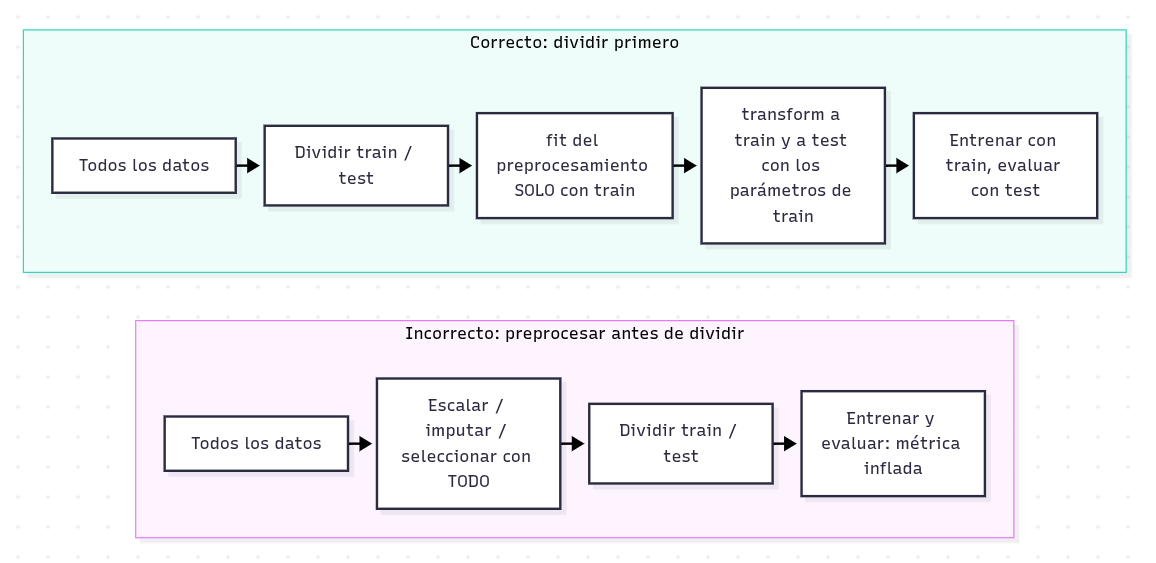

## 4. La Solución: `Pipeline` + `ColumnTransformer` 🔧

Un `Pipeline` encadena el preprocesamiento y el modelo en **un único estimador**: `fit` aprende los parámetros de cada paso **solo con los datos que recibe**, y `predict` aplica esos mismos parámetros a datos nuevos. Un `ColumnTransformer` permite dar a cada grupo de columnas su propio tratamiento. Ventajas:

1. **Evita la fuga:** dentro de `cross_val_score` o `GridSearchCV`, cada fold reajusta todo con sus datos de entrenamiento.
2. **Reproducibilidad:** el mismo objeto sirve en entrenamiento y en producción; no hay pasos manuales que olvidar.
3. **Código más limpio:** un solo `.fit()` y un solo `.predict()`.

Comprobémoslo con una separación entrenamiento/prueba explícita: ajustamos el pipeline completo y verificamos que los estadísticos aprendidos provienen **únicamente** del entrenamiento.

In [ ]:
# ============================================================
# 4. Pipeline final: ajuste solo con train y verificacion de que no hay fuga
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)

modelo_final = Pipeline([("prep", prep4), ("knn", nuevo_knn())])
modelo_final.fit(X_tr, y_tr)                                  # TODO se aprende con X_tr
auc_test = roc_auc_score(y_te, modelo_final.predict_proba(X_te)[:, 1])
print(f"AUC en el conjunto de prueba (datos no vistos): {auc_test:.3f}")

# --- Verificacion: las medianas del imputador provienen del entrenamiento, no de todo el dataset ---
imp = modelo_final.named_steps["prep"].named_transformers_["num"].named_steps["imputador"]
comparacion = pd.DataFrame({"mediana_aprendida_por_el_pipeline": imp.statistics_,
                            "mediana_de_X_train": X_tr[columnas_num].median().values,
                            "mediana_de_TODO_X": X[columnas_num].median().values}, index=columnas_num)
display(comparacion.round(2))
print("Coincide con train:", np.allclose(imp.statistics_, X_tr[columnas_num].median().values))
print("Coincide con todo el dataset:", np.allclose(imp.statistics_, X[columnas_num].median().values), "(no deberia, salvo casualidad)")

# --- Nombres de las variables que recibe el modelo tras el preprocesamiento ---
nombres = modelo_final.named_steps["prep"].get_feature_names_out()
print(f"\nEl modelo recibe {len(nombres)} variables transformadas:")
print(list(nombres))

# --- Robustez ante categorias nunca vistas en train (handle_unknown='ignore') ---
cliente_nuevo = X_te.iloc[[0]].copy()
cliente_nuevo["ciudad"] = "Ciudad_Nueva"
print(f"\nPrediccion para un cliente de una ciudad no vista en train: P(incumple) = {modelo_final.predict_proba(cliente_nuevo)[0, 1]:.3f}")

---
## 5. Checklist de Preprocesamiento ✅

Usa esta lista antes de entrenar cualquier modelo. La última columna indica dónde se **ajusta** cada paso: **todo lo que "aprende" de los datos debe ajustarse solo con el conjunto de entrenamiento**.

| # | Pregunta | Acción típica | Herramienta | ¿Se ajusta con datos? |
|---|---|---|---|---|
| 1 | ¿Entiendo qué significa cada variable y **cuándo** está disponible? | Descartar variables "del futuro" | Conocimiento del dominio | No |
| 2 | ¿Dividí **antes** de transformar? | Separar train/test (y validación) | `train_test_split` | No |
| 3 | ¿Hay duplicados o errores de formato? | Deduplicar, corregir tipos | `pandas` | No |
| 4 | ¿Hay valores faltantes? ¿Por qué faltan? | Imputar o marcar con indicador | `SimpleImputer`, `KNNImputer` | **Sí** |
| 5 | ¿Hay valores atípicos? ¿Son errores o casos reales? | Corregir, recortar o conservar | `RecorteIQR` (Sec. 2), `RobustScaler` | **Sí** |
| 6 | ¿Las escalas son comparables (si el modelo es sensible)? | Estandarizar o normalizar | `StandardScaler`, `MinMaxScaler` | **Sí** |
| 7 | ¿Hay variables categóricas? | Codificar | `OneHotEncoder`, `OrdinalEncoder` | **Sí** |
| 8 | ¿Hay demasiadas variables o muy correlacionadas? | Seleccionar o reducir | `SelectKBest`, `PCA` | **Sí** |
| 9 | ¿Todo está dentro de un `Pipeline`/`ColumnTransformer`? | Encadenar con el modelo | `Pipeline`, `ColumnTransformer` | — |
| 10 | ¿Mi métrica es honesta? ¿Hay una línea base? | Validación cruzada + `Dummy*` | `cross_val_score` | — |

### Para profundizar (sin repetir aquí lo que ya se estudia allá)

- ⛏️ **Data Mining — Módulo 01 (Preprocesamiento):** [Valores faltantes e imputación](../../Data%20Mining/01%20-%20Preprocesamiento%20de%20los%20Datos/00_Tratamiento_de_Valores_Faltantes_e_Imputacion.ipynb) · [Valores atípicos](../../Data%20Mining/01%20-%20Preprocesamiento%20de%20los%20Datos/01_Deteccion_y_Tratamiento_de_Valores_Atipicos_Outliers.ipynb) · [Escalado y normalización](../../Data%20Mining/01%20-%20Preprocesamiento%20de%20los%20Datos/02_Escalado_Transformacion_y_Normalizacion.ipynb) · [Codificación de categóricas](../../Data%20Mining/01%20-%20Preprocesamiento%20de%20los%20Datos/03_Codificacion_de_Variables_Categoricas.ipynb) · [Reducción de dimensionalidad con PCA](../../Data%20Mining/01%20-%20Preprocesamiento%20de%20los%20Datos/04_Reduccion_de_Dimensionalidad_con_PCA.ipynb).
- 🐍 **Data Science Programming — Módulo 05 (Data Preparation):** [Introducción a la preparación de datos](../../Data%20Science%20programming/05%20-%20Data%20Preparation/00_Introduccion_Data_Preparation.ipynb) · [Valores faltantes](../../Data%20Science%20programming/05%20-%20Data%20Preparation/01_Valores_Faltantes_Data_Preparation.ipynb) · [Escalado de características](../../Data%20Science%20programming/05%20-%20Data%20Preparation/02_Escalado_Caracteristicas_Data_Preparation.ipynb).

---
##### 🛠️ Práctica 1: Una variante de la escalera: `RobustScaler` en lugar de recortar

La escalera de la Sección 2 resolvió los atípicos con `RecorteIQR` + `StandardScaler` (nivel **E4**). Otra opción, mencionada en la tabla de la Sección 1, es el `RobustScaler`, que escala con la **mediana** y el **rango intercuartílico** (menos sensibles a valores extremos). Usa `X`, `y`, `columnas_num`, `columnas_cat`, `pipe_cat()`, `nuevo_knn()`, `evaluar()` y `tabla`:

1. Importa `RobustScaler` de `sklearn.preprocessing` y arma un `ColumnTransformer` llamado `prep_rob`: para las numéricas, imputación por mediana + `RobustScaler` (**sin** `RecorteIQR`); para las categóricas, `pipe_cat()`.
2. Encadénalo con `nuevo_knn()` en un `Pipeline` (`m_rob`) y evalúalo con `evaluar("E4b + RobustScaler", m_rob, X[columnas_num + columnas_cat], y)`; guarda el resultado en `fila_rob`.
3. Muestra en un `DataFrame` llamado `comparacion` los niveles **E3** y **E4** de `tabla` (`tabla.iloc[[3, 4]]`) junto con tu nivel **E4b**.
4. Verifica con `assert` que E4b no empeora a E3 (`AUC_media`) y comenta: ¿queda más cerca de E3 o de E4? Compara la diferencia con la desviación (`AUC_desv`).

In [ ]:
# Escribe tu código aquí

# from sklearn.preprocessing import RobustScaler
# prep_rob = ColumnTransformer([
#     ("num", Pipeline([("imputador", ...), ("escalador", ...)]), columnas_num),
#     ("cat", pipe_cat(), columnas_cat)])
# m_rob = Pipeline([("prep", prep_rob), ("knn", nuevo_knn())])
# fila_rob = evaluar(...)
# comparacion = pd.concat([tabla.iloc[[3, 4]], pd.DataFrame([fila_rob]).set_index("nivel")])


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
from sklearn.preprocessing import RobustScaler

# Numericas: imputar con mediana y escalar con mediana/IQR (robusto a atipicos), sin recorte previo
prep_rob = ColumnTransformer([
    ("num", Pipeline([("imputador", SimpleImputer(strategy="median")),
                      ("escalador", RobustScaler())]), columnas_num),
    ("cat", pipe_cat(), columnas_cat)])
m_rob = Pipeline([("prep", prep_rob), ("knn", nuevo_knn())])

fila_rob = evaluar("E4b + RobustScaler", m_rob, X[columnas_num + columnas_cat], y)

comparacion = pd.concat([tabla.iloc[[3, 4]], pd.DataFrame([fila_rob]).set_index("nivel")])
display(comparacion.round(3))

assert fila_rob["AUC_media"] >= tabla["AUC_media"].iloc[3]
print("El escalado robusto no empeora a E3 y queda entre E3 y E4: ayuda, pero recortar antes de escalar rinde algo mas.")
```
</details>

---


---
##### 🛠️ Práctica 2: Cazando una variable "del futuro"

En la Sección 3.1 sabíamos de antemano que `dias_mora_posteriores` era una fuga del objetivo. En la vida real hay que **detectarla**. Con el `DataFrame` `X_fuga` (que ya la incluye), `y`, `columnas_num` y `roc_auc_score` (de `sklearn.metrics`):

1. Define `candidatas = columnas_num + ["dias_mora_posteriores"]`.
2. Para cada columna, rellena sus faltantes con su mediana y calcula el AUC univariado contra `y` usando la propia columna como "puntaje"; como la dirección no importa, quédate con `max(auc, 1 - auc)`. Guarda todo en una `Series` ordenada de mayor a menor llamada `auc_univariado`.
3. Identifica la columna sospechosa (la de mayor AUC) en `sospechosa` e imprime la tabla.
4. Construye `X_limpio = X_fuga.drop(columns=sospechosa)` y verifica con `assert` que `sospechosa == "dias_mora_posteriores"` y que `X_limpio` vuelve a tener exactamente las columnas de `X`.

In [ ]:
# Escribe tu código aquí

# candidatas = columnas_num + ["dias_mora_posteriores"]
# aucs = {}
# for col in candidatas:
#     valores = X_fuga[col].fillna(...)
#     auc = roc_auc_score(y, valores)
#     aucs[col] = max(auc, 1 - auc)
# auc_univariado = pd.Series(aucs).sort_values(ascending=False)
# sospechosa = ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
candidatas = columnas_num + ["dias_mora_posteriores"]

aucs = {}
for col in candidatas:
    valores = X_fuga[col].fillna(X_fuga[col].median())      # imputacion simple solo para este diagnostico
    auc = roc_auc_score(y, valores)                          # la columna actua como "puntaje"
    aucs[col] = max(auc, 1 - auc)                            # ignoramos la direccion de la relacion

auc_univariado = pd.Series(aucs).sort_values(ascending=False)
print(auc_univariado.round(3).to_string())

sospechosa = auc_univariado.index[0]
print(f"\nVariable sospechosa (AUC univariado sospechosamente alto): {sospechosa}")

X_limpio = X_fuga.drop(columns=sospechosa)
assert sospechosa == "dias_mora_posteriores"
assert list(X_limpio.columns) == list(X.columns)
print("Variable del futuro eliminada: X_limpio vuelve a tener solo informacion disponible al decidir el credito.")
```
</details>

---


---
##### 🛠️ Práctica 3: ¿Cuántas variables selecciono? Ruido puro con distintos $k$

En la Sección 3.2 la fuga aparecía al seleccionar 20 variables antes de validar. ¿Depende del número de variables elegidas? Repite el experimento con `X_ruido`, `y_ruido`, `cv5` y las clases `SelectKBest`, `f_classif` y `LogisticRegression` (ya importadas):

1. Para cada $k$ en `[5, 20, 100, 500]` calcula el *accuracy* de validación cruzada del procedimiento **incorrecto** (seleccionar con todos los datos y luego validar) y del **correcto** (selección dentro de un `Pipeline`).
2. Guarda los resultados en un `DataFrame` llamado `barrido_k` (índice = $k$; columnas `incorrecto` y `correcto`) e imprímelo.
3. Verifica con `assert` que el procedimiento correcto queda cerca del azar (entre $0.3$ y $0.7$ para todo $k$) y que, en promedio, el incorrecto **supera** al correcto.

In [ ]:
# Escribe tu código aquí

# filas = {}
# for k in [5, 20, 100, 500]:
#     # incorrecto: seleccion con TODOS los datos y despues validacion cruzada
#     X_sel = SelectKBest(f_classif, k=k).fit_transform(..., ...)
#     acc_inc = cross_val_score(LogisticRegression(max_iter=1000), X_sel, y_ruido, cv=cv5).mean()
#     # correcto: la seleccion vive dentro de un Pipeline
#     pipe = Pipeline([...])
#     acc_cor = ...
#     filas[k] = {"incorrecto": acc_inc, "correcto": acc_cor}
# barrido_k = pd.DataFrame(filas).T


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
filas = {}
for k in [5, 20, 100, 500]:
    # INCORRECTO: la seleccion ve las etiquetas de todas las filas, tambien las de validacion
    X_sel = SelectKBest(f_classif, k=k).fit_transform(X_ruido, y_ruido)
    acc_inc = cross_val_score(LogisticRegression(max_iter=1000), X_sel, y_ruido, cv=cv5).mean()
    # CORRECTO: la seleccion se reajusta con el entrenamiento de cada fold
    pipe = Pipeline([("seleccion", SelectKBest(f_classif, k=k)), ("lr", LogisticRegression(max_iter=1000))])
    acc_cor = cross_val_score(pipe, X_ruido, y_ruido, cv=cv5).mean()
    filas[k] = {"incorrecto": acc_inc, "correcto": acc_cor}

barrido_k = pd.DataFrame(filas).T
barrido_k.index.name = "k"
print(barrido_k.round(3))

assert barrido_k["correcto"].between(0.3, 0.7).all()
assert barrido_k["incorrecto"].mean() > barrido_k["correcto"].mean()
print("Sea cual sea k, el procedimiento honesto ronda el azar; el contaminado 'encuentra' patrones que no existen.")
```
</details>

---


---
## Resumen y Puntos Clave 🎯

| Concepto | Mensaje Central |
|---|---|
| **GIGO** | Un modelo no puede extraer información que los datos no contienen ni corregir errores que ignora |
| **Cuatro frentes** | Faltantes, escalas distintas, categóricas y atípicos: cada uno tiene su remedio y puede cambiar el resultado de forma medible |
| **Demostración** | El mismo *k*-NN mejoró paso a paso al imputar, escalar, codificar y recortar atípicos (sección 2) |
| **Sensibilidad al modelo** | *k*-NN, K-Means, SVM y modelos lineales regularizados exigen escalado; los árboles casi no |
| **Fuga de datos** | Usar información que no existiría en producción: variables "del futuro" o estadísticas calculadas con los datos de prueba |
| **Regla de oro** | Primero dividir; todo lo que "aprende" de los datos se ajusta **solo con train** |
| **`Pipeline` + `ColumnTransformer`** | Garantizan lo anterior de forma automática, incluso dentro de la validación cruzada |

> 🎓 **Cierre del Módulo 00:** ya sabes qué es aprender (Mitchell), de qué maneras se aprende (paradigmas), qué problemas se resuelven (tipos) y por qué los datos deben prepararse con rigor. Ahora pon todo en práctica en el taller [`../homeworks/00_Introduccion_ML_Hands_On.ipynb`](../homeworks/00_Introduccion_ML_Hands_On.ipynb).

---
### 🧠 Autoevaluación

1. En la escalera de la Sección 2, ¿qué paso crees que habría aportado **menos** si el modelo hubiera sido un árbol de decisión en lugar de *k*-NN? Justifica tu respuesta.
2. Un analista imputa los faltantes con la media de **todo el dataset**, luego divide en train y test y reporta un AUC de 0.91. Explica por qué esa cifra puede estar inflada y cómo lo corregirías.
3. Una variable `fecha_cierre_del_caso` aparece como la más importante de un modelo que predice si un reclamo será aprobado. ¿Qué sospecharías y cómo lo verificarías con el equipo del negocio?
4. Elige un conjunto de datos de tu entorno laboral o académico y recorre el checklist de la Sección 5: ¿cuáles de los 10 puntos tendrían hoy una respuesta negativa?

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Asignatura: Machine Learning</i>
  </p>
</div>